<img src="filter.png" />

<div dir="rtl" align="right">
<b>استيراد المكتبات</b><br>
نستورد مكتبة <code>cv2</code> لمعالجة الصور، و<code>matplotlib</code> لعرضها، و<code>numpy</code> لإنشاء نوى الفلاتر (Kernels) يدوياً.
</div>

In [36]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

<div dir="rtl" align="right">
<b>قراءة الصورة الأصلية</b><br>
نحمّل صورة الأزهار من القرص وتُخزَّن في المتغير <code>image</code> بنظام BGR.
</div>

In [37]:
image = cv2.imread('flowers.jpg')

<div dir="rtl" align="right">
<b>عرض الصورة الأصلية</b><br>
نعرض الصورة الأصلية قبل تطبيق أي فلتر كمرجع للمقارنة مع النتائج.
</div>

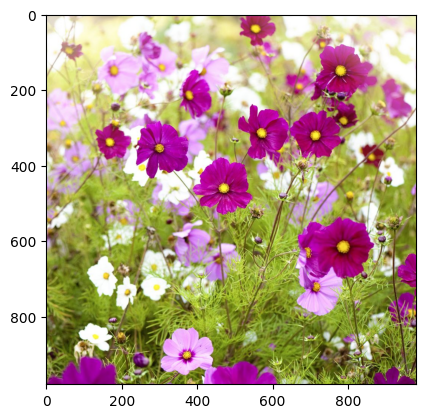

In [38]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

<div dir="rtl" align="right">
<b>تعريف نوى الفلاتر (Kernels)</b><br>
نعرّف نواتين للفلترة يدوياً باستخدام NumPy:<br>
— <b>kernel</b> (نواة الحدة - Sharpening): تضخّم قيمة البكسل المركزي (9) وتطرح قيم الجيران (-1)، مما يبرز الحواف ويزيد حدة الصورة.<br>
— <b>kernel2</b> (نواة Sobel الرأسية): تكشف الحواف الرأسية في الصورة عن طريق حساب التدرج الأفقي في شدة الإضاءة.
</div>

In [46]:
kernel = np.array([[-1,-1,-1],[-1,9,-1],[-1,-1,-1]])

kernel2 = np.array([[1,0,-1],[2,1,-2],[1,0,-1]])

<div dir="rtl" align="right">
<b>تطبيق الفلتر المخصص باستخدام filter2D</b><br>
نستخدم <code>cv2.filter2D()</code> لتطبيق نواة الفلتر على الصورة بعملية الالتفاف (Convolution).<br>
— <code>src</code>: الصورة المدخلة.<br>
— <code>ddepth=-1</code>: عمق الصورة الناتجة يساوي عمق المدخلة (uint8).<br>
— <code>kernel</code>: النواة المراد تطبيقها، هنا نستخدم kernel2 لكشف الحواف الرأسية.
</div>

In [49]:
sharp = cv2.filter2D(src = image, ddepth=-1, kernel= kernel2)

<div dir="rtl" align="right">
<b>عرض الصورة بعد تطبيق الفلتر المخصص</b><br>
نعرض الصورة بعد تطبيق نواة Sobel. ستبدو الحواف الرأسية بارزة بينما المناطق المتجانسة تظهر داكنة.
</div>

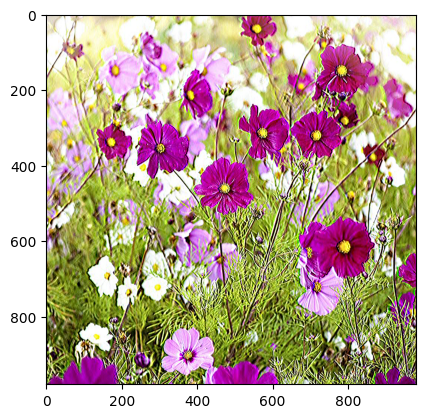

In [50]:
plt.imshow(cv2.cvtColor(sharp, cv2.COLOR_BGR2RGB))
plt.show()

<div dir="rtl" align="right">
<b>تطبيق فلتر التمويه (Blur)</b><br>
نستخدم <code>cv2.blur()</code> لتطبيق فلتر المتوسط (Averaging Filter) الذي يحسب متوسط قيم البكسلات في نافذة 10×10 ويضع النتيجة في البكسل المركزي.<br>
النتيجة صورة ضبابية (Blurred) تُستخدم لتقليل الضوضاء أو تنعيم التفاصيل الدقيقة.
</div>

In [54]:
img_blur = cv2.blur(src = image, ksize=(10,10))

<div dir="rtl" align="right">
<b>عرض الصورة بعد التمويه</b><br>
نعرض الصورة بعد تطبيق فلتر المتوسط. لاحظ ضياع التفاصيل الدقيقة وظهور الصورة بشكل ضبابي بسبب حجم النافذة الكبير (10×10).
</div>

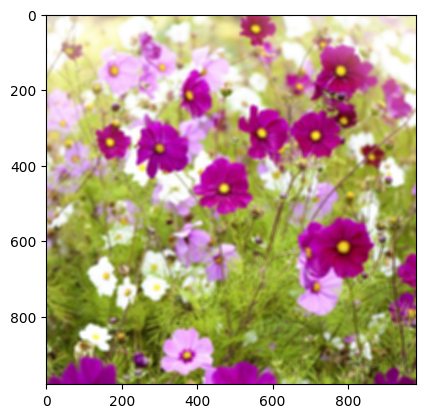

In [55]:
plt.imshow(cv2.cvtColor(img_blur, cv2.COLOR_BGR2RGB))
plt.show()

<div dir="rtl" align="right">
<b>تطبيق الفلتر الثنائي (Bilateral Filter)</b><br>
نستخدم <code>cv2.bilateralFilter()</code> وهو فلتر ذكي يُنعّم الصورة مع الحفاظ على الحواف، على عكس فلتر المتوسط الذي يطمس كل شيء.<br>
— <code>d=20</code>: قطر منطقة الجيران المستخدمة في الفلترة.<br>
— <code>sigmaColor=75</code>: مدى الألوان المسموح بدمجها معاً (فرق اللون المقبول).<br>
— <code>sigmaSpace=75</code>: تأثير المسافة المكانية، كلما زادت القيمة كلما تأثرت البكسلات البعيدة أكثر.
</div>

In [56]:
bi_let_filter = cv2.bilateralFilter(src= image, d=20, sigmaColor=75,sigmaSpace =75)

<div dir="rtl" align="right">
<b>عرض الصورة بعد الفلتر الثنائي</b><br>
نعرض الصورة بعد تطبيق الفلتر الثنائي. لاحظ كيف تبقى الحواف والتفاصيل الرئيسية واضحة بينما تختفي الضوضاء الدقيقة، مما يجعله مثالياً لمعالجة الصور الاحترافية.
</div>

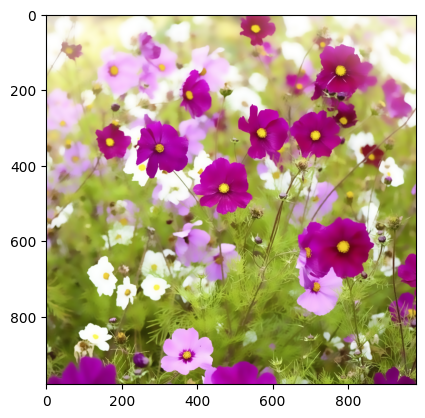

In [57]:
plt.imshow(cv2.cvtColor(bi_let_filter, cv2.COLOR_BGR2RGB))
plt.show()

<img src="Bilateral.png" />